<a href="https://colab.research.google.com/github/JoaoAntoni07/estudo-catijr/blob/main/semana-04/semana04_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 04

## Dataset escolhido

### O dataset escolhido para a resolução do problema foi o "pokemon". Este dataset pode ser encontrado no github, pelo link: https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv. O dataset traz os seguintes dados sobre os pokémons:
- Name: Nome do Pokémon.
- Type 1 / Type 2: O tipo principal e secundário.
- Total: A soma de todos os atributos de combate.
- HP: Pontos de vida.
- Attack / Defense: Poder de ataque físico e resistência física.
- Sp. Atk / Sp. Def: Poder de ataque especial e resistência especial.
- Speed: Velocidade de ataque.
- Generation: A geração em que o Pokémon foi lançado (1 a 6).
- Legendary: Valor indicando se é um Pokémon lendário (True) ou comum (False).

## Limpeza dos dados

### Iremos realizar uma "faxina" no dataset para identificar se existem falhas nele, como por exemplo valores nulos. Caso as falhas sejam encontradas, iremos tratá-las da maneira correta.

## Análise dos dados

### Nesse dataset, iremos analisar duas questões, que serão respondidas através do código:
- A média de poder total do tipo lendário é significativamente maior do que a média de poder total do tipo comum?
- Pensando apenas no Tipo Principal, qual tipo de Pokémon tem a maior média de poder de Ataque?

## Vizualização

### Após todas as descobertas feitas pelos passos anteriores, iremos mostrar graficamente a análise.

## Resolução:

In [1]:
# importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 1- criando o dataframe
url = 'https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv'
df = pd.read_csv(url)
print('Vizualizando as cinco primeiras linhas do dataset: ')
df.head()

Vizualizando as cinco primeiras linhas do dataset: 


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [4]:
# 2- recolhendo informações sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [5]:
# 3- tratamento dos dados
# 3.1- procurando por valores nulos
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [21]:
# 3.2- tomando decisão sobre o que fazer com os valores nulos
# como os valores nulos estão presentes na coluna Type 2, isso nos conta que muitos pokémons possuem apenas o tipo primário, logo iremos preencher os valores com vazios com 'None'
df['Type 2'].fillna('None', inplace=True)

/tmp/ipykernel_4253/315034770.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type 2'].fillna('None', inplace=True)


In [22]:
# 3.3- verificando se deu certo
print(df.isnull().sum())

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [8]:
# garantindo que não há linhas repetidas
df.drop_duplicates()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [9]:
# 4- resumo estático do dataset
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [16]:
# 5- respondendo as questões levantadas
# 5.1- verificando se a média total dos lendários é significativamente maior do que a média total dos comuns
media_lendarios = df[df['Legendary'] == True]['Total'].mean()
media_comuns = df[df['Legendary'] == False]['Total'].mean()

print(f"Média de poder dos Comuns: {media_comuns:.2f}")
print(f"Média de poder dos Lendários: {media_lendarios:.2f}")

# comparando as médias
comparacao_media = media_comuns / media_lendarios
if comparacao_media > 0.9:
  print(f"Os pokémons lendários são, em média, {1 - comparacao_media:.2f}% mais fortes, logo a diferenção NÃO É tão significativa.")
else:
  print(f"Os pokémons lendários são, em média, {1 - comparacao_media:.2f}% mais fortes, logo a diferenção É significativa.")

Média de poder dos Comuns: 417.21
Média de poder dos Lendários: 637.38
Os pokémons lendários são, em média, 0.35% mais fortes, logo a diferenção É significativa.


In [20]:
# 5.2- verificando qual tipo principal de pokémon tem a maior média de poder de ataque
ranking_ataque = df.groupby('Type 1')['Attack'].mean().sort_values(ascending=False)
print(ranking_ataque)
print(f"Logo, o tipo principal de pokémon que apresenta maior média de poder de ataque é o tipo Dragão.")

Type 1
Dragon      112.125000
Fighting     96.777778
Ground       95.750000
Rock         92.863636
Steel        92.703704
Dark         88.387097
Fire         84.769231
Flying       78.750000
Poison       74.678571
Water        74.151786
Ghost        73.781250
Normal       73.469388
Grass        73.214286
Ice          72.750000
Psychic      71.456140
Bug          70.971014
Electric     69.090909
Fairy        61.529412
Name: Attack, dtype: float64
Logo, o tipo principal de pokémon que apresenta maior média de poder de ataque é o tipo Dragão.


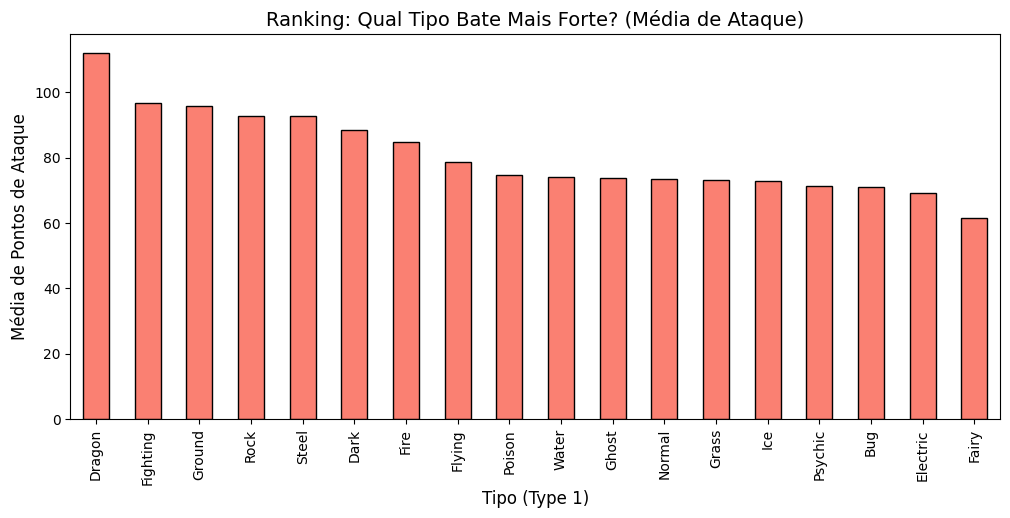

In [26]:
# 6- visualização
# criando gŕafico sobre o segundo tópico analisado
ranking_ataque.plot(kind='bar', figsize=(12, 5), color='salmon', edgecolor='black')
plt.title('Ranking: Qual Tipo Bate Mais Forte? (Média de Ataque)', fontsize=14)
plt.xlabel('Tipo (Type 1)', fontsize=12)
plt.ylabel('Média de Pontos de Ataque', fontsize=12)
plt.show()